### Flow Matching Ergodic Coverage Tutorial
#### 2D coverage using Stein variational gradient flow with the second-order point-mass dynamics

This tutorial uses [`lqrax`](https://github.com/MaxMSun/lqrax/tree/main) to solve the continuous time Riccati equation for the LQ flow matching problem.

In [1]:
import time
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import jax.numpy as jnp
import os
import numpy as np

from jax import jit, grad, vmap, jacfwd
from jax.scipy.stats import gaussian_kde as kde
from jax.scipy.stats import multivariate_normal as mvn
import jax
cpu = jax.devices("cpu")[0]
try:
    gpu = jax.devices("cuda")[0]
except:
    gpu = cpu
jnp.set_printoptions(precision=4)

try:
    from lqrax import LQR
except:
    %pip install lqrax
    from lqrax import LQR

In [2]:
mean1 = jnp.array([0.3, 0.5])
cov1 = jnp.array([
    [0.002, 0.0],
    [0.0, 0.04]
])

mean2 = jnp.array([0.5, 0.5])
cov2 = jnp.array([
    [0.02, -0.018],
    [-0.018, 0.02]
])

mean3 = jnp.array([0.7, 0.5])
cov3 = jnp.array([
    [0.002, 0.0],
    [0.0, 0.04]
])

w1, w2, w3 = 0.34, 0.34, 0.33

# --- OBSTACLE PARAMETERS ---
# Change these values to move or resize the obstacle!
OBS_X = 0.5          # X-coordinate of the obstacle center
OBS_Y = 0.5         # Y-coordinate of the obstacle center
OBS_RADIUS = 0.05    # How wide the obstacle is
OBS_STIFFNESS = 4.0 # How strongly it pushes particles away
# ---------------------------

In [3]:
# # A different target distribution
# mean1 = jnp.array([0.30, 0.5])
# cov1 = jnp.array([
#     [0.003, 0.0],
#     [0.0, 0.05]
# ])

# mean2 = jnp.array([0.5, 0.25])
# cov2 = jnp.array([
#     [0.02, -0.0],
#     [-0.0, 0.002]
# ])

# mean3 = jnp.array([0.70, 0.5])
# cov3 = jnp.array([
#     [0.003, 0.0],
#     [0.0, 0.05]
# ])

# w1, w2, w3 = 0.5, 0.25, 0.5

In [4]:
def pdf(x):
    # only evaluate the first two dimensions (2D position)
    val1 = w1 * mvn.pdf(x[:2], mean1, cov1)
    val2 = w2 * mvn.pdf(x[:2], mean2, cov2)
    val3 = w3 * mvn.pdf(x[:2], mean3, cov3)
    return val1 + val2 + val3

def obstacle_penalty(x):
    # Read from the global variables defined above
    obs_center = jnp.array([OBS_X, OBS_Y]) 
    
    # Calculate the squared distance from the particle to the obstacle
    dist_sq = jnp.sum((x[:2] - obs_center)**2)
    
    # Return the penalty
    return OBS_STIFFNESS * jnp.exp(-dist_sq / (2 * OBS_RADIUS**2))

def log_pdf(x):
    return jnp.log(pdf(x)) - obstacle_penalty(x)


score_pdf = grad(log_pdf)

In [5]:
# Density grid for visualizing PDF
grids_x, grids_y = jnp.meshgrid(
    jnp.linspace(0.0, 1.0, 100),
    jnp.linspace(0.0, 1.0, 100)
)
grids = jnp.array([grids_x.ravel(), grids_y.ravel()]).T
print(f'grids.shape: {grids.shape}')

grids.shape: (10000, 2)


In [6]:
# Less dense grid for visualizing score function (vector field)
grids_x2, grids_y2 = jnp.meshgrid(
    jnp.linspace(0.1, 0.9, 30),
    jnp.linspace(0.1, 0.9, 30)
)
grids2 = jnp.array([grids_x2.ravel(), grids_y2.ravel()]).T
print(f'grids2.shape: {grids2.shape}')

grids2.shape: (900, 2)


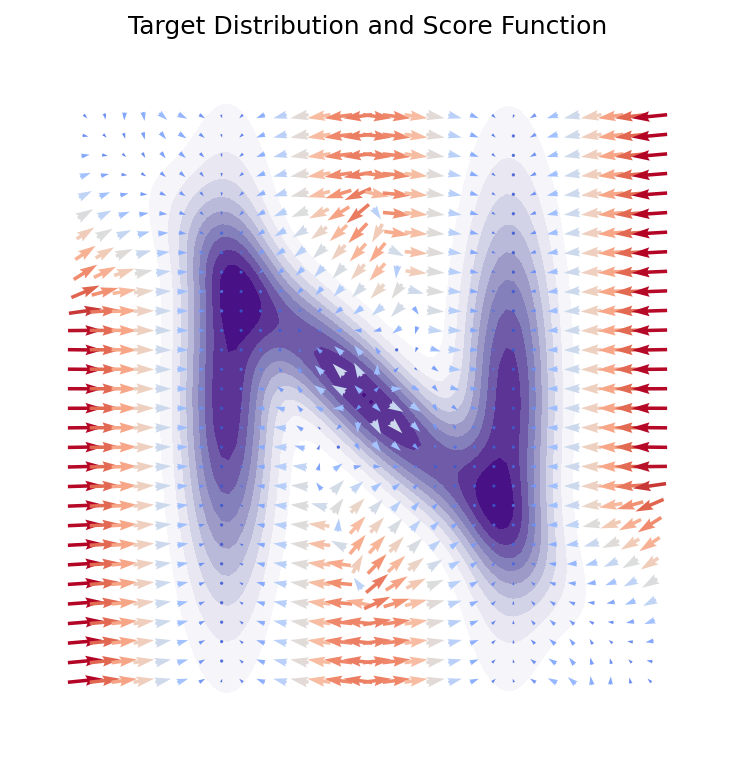

In [7]:
pdf_grids = vmap(pdf)(grids).reshape(grids_x.shape)
pdf_grids = np.array(pdf_grids)
# cannot reshape here because it is a vector field
score_grids = vmap(score_pdf)(grids2)

fig, ax = plt.subplots(1, 1, figsize=(5, 6), dpi=150, tight_layout=True)
ax.set_title("Target Distribution and Score Function")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect('equal')
ax.axis('off')
clevels = np.linspace(pdf_grids.min(), pdf_grids.max(), 11)
ax.contourf(grids_x, grids_y, pdf_grids, levels=clevels[1:], cmap='Purples')
ax.quiver(
    grids_x2, grids_y2,
    score_grids[:, 0], score_grids[:, 1],
    np.sqrt(np.sum(score_grids**2, axis=-1)),
    cmap="coolwarm",
    scale=2000.0,
    width=0.005,
    pivot="mid",
)
plt.show()
plt.close()

In [8]:
import jax.numpy as jnp

dt = 0.05
tsteps = 200
T = dt * tsteps
times = jnp.linspace(0, T, tsteps)

# 1) Linear movement on X-axis (from 0.1 to 0.9)
px = jnp.linspace(0.1, 0.9, tsteps)

# 2) Constant or Linear movement on Y-axis (fixed at 0.5)
# If you want a diagonal line, change the second number to something else (e.g., 0.1 to 0.9)
py = jnp.linspace(0.5, 0.5, tsteps) 

# 3) Combine into trajectory
linear_traj = jnp.stack([px, py], axis=-1)

# 4) Initial State (x0)
# Position + Velocity. Since it's linear, velocity is (delta_pos / dt)
vx = (px[1] - px[0]) / dt
vy = (py[1] - py[0]) / dt

x0 = jnp.array([
    px[0], 
    py[0], 
    vx, 
    vy
])

# 5) Control Trajectory (u_traj)
# For a perfectly linear path, acceleration is zero.
u_traj = jnp.zeros((tsteps, 2))

# For your Plotly visualization
x_traj_list = [linear_traj]

In [9]:
class PointMassLQR(LQR):
    def __init__(self, dt, x_dim, u_dim, Q, R):
        super().__init__(dt, x_dim, u_dim, Q, R)

    def dyn(self, xt, ut):
        return jnp.array([xt[2], xt[3], ut[0], ut[1]])

In [10]:
Q = jnp.diag(jnp.array([1.0, 1.0, 0.001, 0.001]))
R = jnp.diag(jnp.array([0.01, 0.01]))
pointmass_lqr = PointMassLQR(dt=dt, x_dim=4, u_dim=2, Q=Q, R=R)

# lqr solving on CPU is faster
linearize_dyn = jit(pointmass_lqr.linearize_dyn, device=cpu)
solve_lqr = jit(pointmass_lqr.solve, device=cpu)

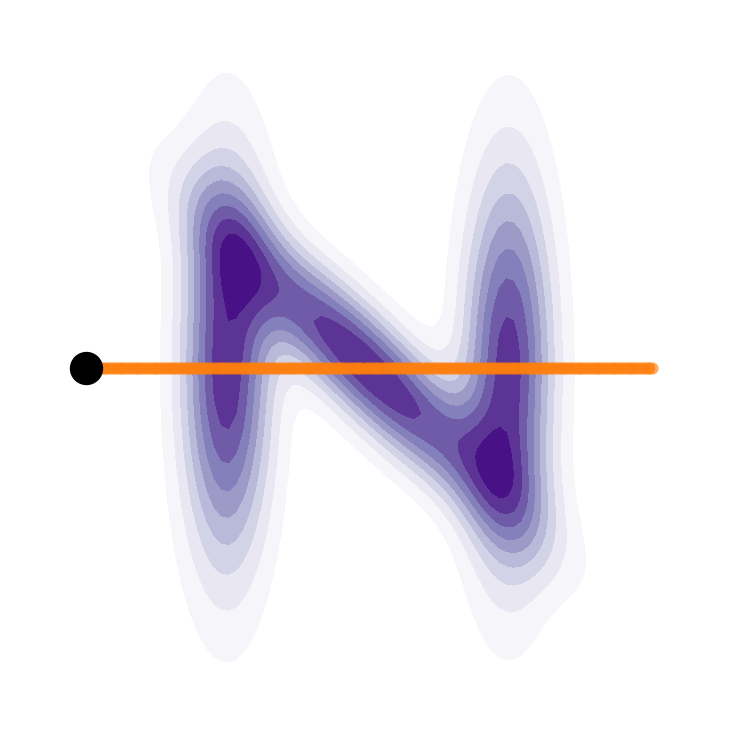

In [11]:
x_traj = pointmass_lqr.traj_sim(x0, u_traj)

fig, ax = plt.subplots(1, 1, figsize=(5, 6), dpi=150, tight_layout=True)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect('equal')
ax.axis('off')
clevels = np.linspace(pdf_grids.min(), pdf_grids.max(), 11)
ax.contourf(grids_x, grids_y, pdf_grids, levels=clevels[1:], cmap='Purples')
ax.plot(x_traj[:, 0], x_traj[:, 1], linestyle='-', linewidth=3,
        marker='o', markersize=5, color='C1', alpha=0.5)
ax.plot(x0[0], x0[1], linestyle='', marker='o', markersize=15, color='k')
plt.show()
plt.close()

In [12]:
# Define function to calculate Stein variational gradient
def kernel(x1, x2, h):
    # same as in the pdf function, only evaluate the first two dimensions
    return jnp.exp(-1.0 * jnp.sum(jnp.square(x1[:2]-x2[:2])) / h)


d_kernel = jax.grad(kernel, argnums=(0))


def stein_grad_unit(x1, x2, h):
    val = kernel(x2, x1, h) * score_pdf(x2) + d_kernel(x2, x1, h)
    return val


def stein_grad_state(x, x_traj, h):
    vals = jax.vmap(stein_grad_unit, in_axes=(None, 0, None))(x, x_traj, h)
    return jnp.mean(vals, axis=0)


def stein_grad(traj, h):
    return jax.vmap(stein_grad_state, in_axes=(0, None, None))(traj, traj, h)


# Stein variational gradient on GPU is faster
stein_grad = jax.jit(stein_grad, device=gpu)

stein_dx_traj .shape: (200, 4) == x_traj.shape: (200, 4)


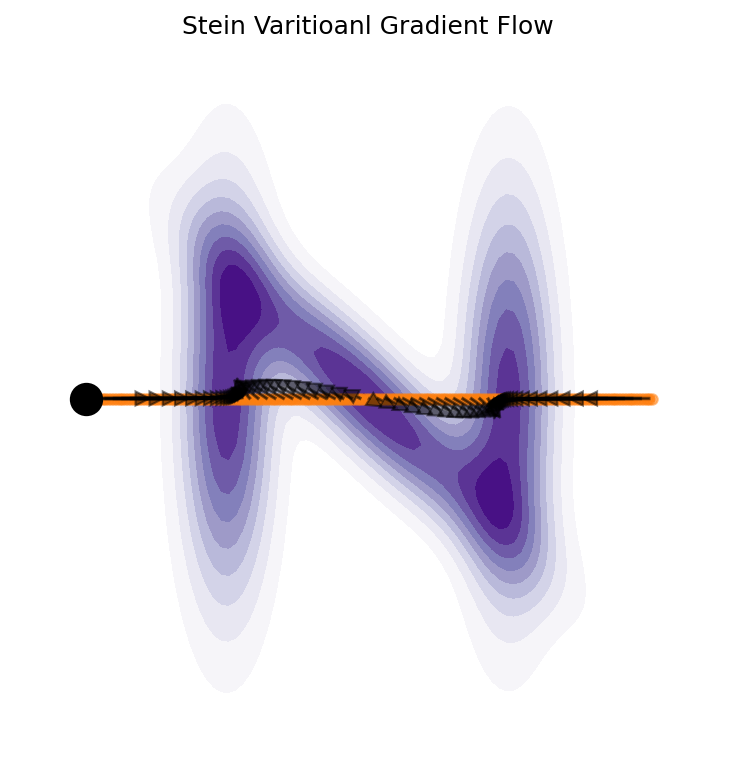

In [13]:
stein_dx_traj = stein_grad(x_traj, h=0.01)
stein_dx_traj = np.array(stein_dx_traj)
# note that the dimension of the descent direction matches the trajectory
print(
    f'stein_dx_traj .shape: {stein_dx_traj.shape} == x_traj.shape: {x_traj.shape}')

fig, ax = plt.subplots(1, 1, figsize=(5, 6), dpi=150, tight_layout=True)
ax.set_title('Stein Varitioanl Gradient Flow')
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect('equal')
ax.axis('off')
clevels = np.linspace(pdf_grids.min(), pdf_grids.max(), 11)
ax.contourf(grids_x, grids_y, pdf_grids, levels=clevels[1:], cmap='Purples')
ax.plot(x_traj[:, 0], x_traj[:, 1], linestyle='-', linewidth=3,
        marker='o', markersize=5, color='C1', alpha=0.5)
for t in range(len(x_traj[::3])):
    vis_scale = 0.01
    ax.arrow(
        x_traj[::3][t, 0], x_traj[::3][t, 1],
        vis_scale * stein_dx_traj[::3][t, 0],
        vis_scale * stein_dx_traj[::3][t, 1],
        width=0.002,
        head_width=0.02,
        head_length=0.02,
        alpha=0.5,
        color='k',
        zorder=2
    )
ax.plot(x0[0], x0[1], linestyle='', marker='o', markersize=15, color='k')
plt.show()
plt.close()

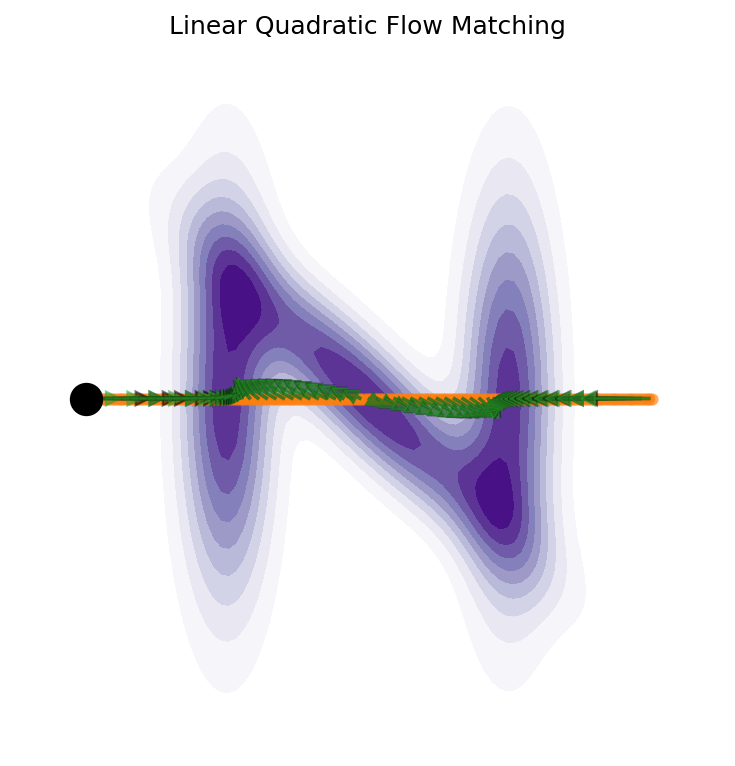

In [14]:
# Solve the LQ flow matching problem for current iteration
x_traj, A_traj, B_traj = linearize_dyn(x0, u_traj)
z0 = jnp.zeros(4)
v_traj, z_traj = solve_lqr(z0, A_traj, B_traj, stein_dx_traj)

fig, ax = plt.subplots(1, 1, figsize=(5, 6), dpi=150, tight_layout=True)
ax.set_title('Linear Quadratic Flow Matching')
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect('equal')
ax.axis('off')
clevels = np.linspace(pdf_grids.min(), pdf_grids.max(), 11)
ax.contourf(grids_x, grids_y, pdf_grids, levels=clevels[1:], cmap='Purples')
ax.plot(x_traj[:, 0], x_traj[:, 1], linestyle='-', linewidth=3,
        marker='o', markersize=5, color='C1', alpha=0.5)
for t in range(len(x_traj[::3])):
    vis_scale = 0.01
    ax.arrow(
        x_traj[::3][t, 0], x_traj[::3][t, 1],
        vis_scale * stein_dx_traj[::3][t, 0],
        vis_scale * stein_dx_traj[::3][t, 1],
        width=0.002,
        head_width=0.02,
        head_length=0.02,
        alpha=0.5,
        color='k',
        zorder=2,
    )
    ax.arrow(
        x_traj[::3][t, 0], x_traj[::3][t, 1],
        vis_scale * z_traj[::3][t, 0],
        vis_scale * z_traj[::3][t, 1],
        width=0.002,
        head_width=0.02,
        head_length=0.02,
        alpha=0.5,
        color='C2',
        zorder=2
    )
ax.plot(x0[0], x0[1], linestyle='', marker='o', markersize=15, color='k')
plt.show()
plt.close()

  0%|          | 0/50000 [00:00<?, ?it/s]

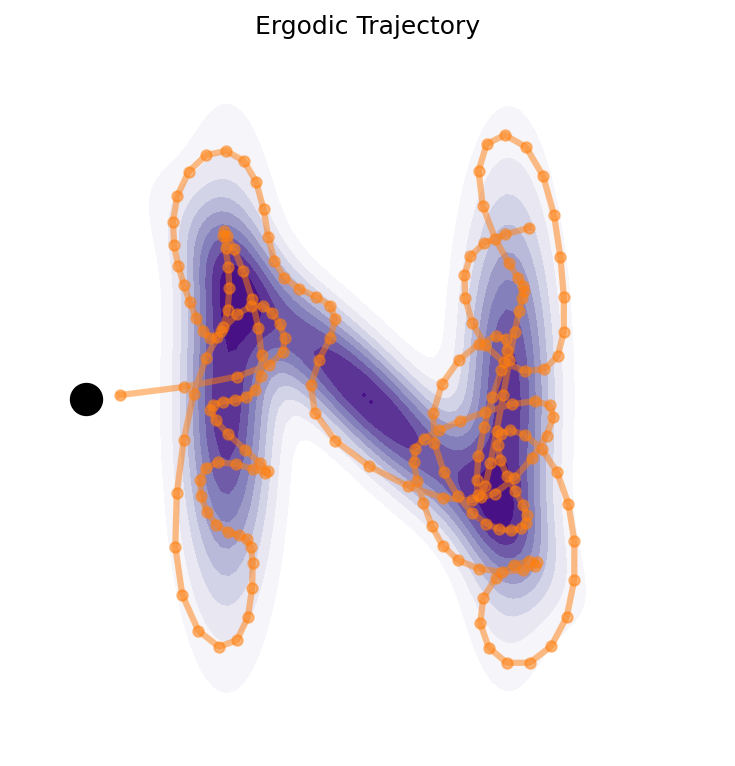

In [15]:
# Solve the flow matching ergodic coverage problem
z0 = jnp.zeros(4)
step_size = 0.01
num_iters = 50000
x_traj_list = []
for i in tqdm(range(num_iters)):
    x_traj, A_traj, B_traj = linearize_dyn(x0, u_traj)
    stein_dx_traj = stein_grad(x_traj, h=0.01)
    v_traj, z_traj = solve_lqr(z0, A_traj, B_traj, stein_dx_traj)
    u_traj += step_size * v_traj 
    x_traj_list.append(np.array(x_traj))
final_x_traj = pointmass_lqr.traj_sim(x0, u_traj)
x_traj_list.append(final_x_traj)
x_traj_list = np.array(x_traj_list)

fig, ax = plt.subplots(1, 1, figsize=(5, 6), dpi=150, tight_layout=True)
ax.set_title('Ergodic Trajectory')
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect('equal')
ax.axis('off')
clevels = np.linspace(pdf_grids.min(), pdf_grids.max(), 11)
ax.contourf(grids_x, grids_y, pdf_grids, levels=clevels[1:], cmap='Purples')
ax.plot(final_x_traj[:, 0], final_x_traj[:, 1], linestyle='-', linewidth=3,
        marker='o', markersize=5, color='C1', alpha=0.5)
ax.plot(x0[0], x0[1], linestyle='', marker='o', markersize=15, color='k')
plt.show()
plt.close()

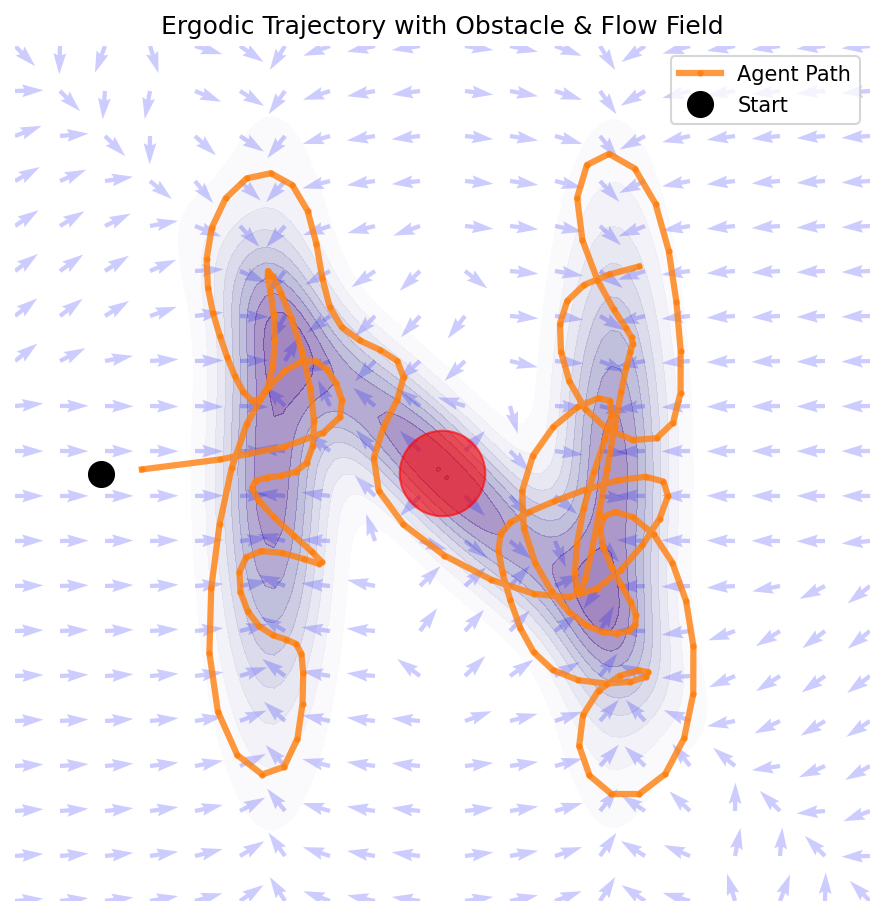

In [16]:
import matplotlib.patches as patches

# --- 2. Calculate the Vector Field (Quiver) ---
# Create a grid for the arrows
y_g, x_g = jnp.meshgrid(jnp.linspace(0, 1, 20), jnp.linspace(0, 1, 20))
grid_points = jnp.stack([x_g.ravel(), y_g.ravel()], axis=1)

# Compute the score (gradient) at each point 
# Ensure score_pdf includes the obstacle penalty!
field_vectors = vmap(score_pdf)(grid_points)
U = field_vectors[:, 0].reshape(20, 20)
V = field_vectors[:, 1].reshape(20, 20)

# Normalize vectors so arrows are the same length (easier to see direction)
mag = jnp.sqrt(U**2 + V**2) + 1e-5
U_norm, V_norm = U/mag, V/mag

# --- 3. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(6, 7), dpi=150, tight_layout=True)
ax.set_title('Ergodic Trajectory with Obstacle & Flow Field')
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect('equal')
ax.axis('off')

# Draw the target distribution (Heatmap)
clevels = np.linspace(pdf_grids.min(), pdf_grids.max(), 11)
ax.contourf(grids_x, grids_y, pdf_grids, levels=clevels[1:], cmap='Purples', alpha=0.5)

# DRAW THE VECTOR FIELD (The "Effects")
ax.quiver(x_g, y_g, U_norm, V_norm, color='blue', alpha=0.2, scale=30, width=0.005)

# DRAW THE OBSTACLE
obstacle_circle = patches.Circle((OBS_X, OBS_Y), OBS_RADIUS, color='red', alpha=0.6, zorder=5)
ax.add_patch(obstacle_circle)

# Draw the calculated trajectory
ax.plot(final_x_traj[:, 0], final_x_traj[:, 1], linestyle='-', linewidth=3,
        marker='o', markersize=2, color='C1', alpha=0.8, label='Agent Path')

# Start point
ax.plot(x0[0], x0[1], linestyle='', marker='o', markersize=12, color='k', label='Start')

plt.legend(loc='upper right')
plt.show()

In [ ]:
import io
import base64
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

# 1) Grab the Matplotlib "C1" color
traj_color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]

# 2) Render the PDF contour to an in-memory PNG via Matplotlib
buf = io.BytesIO()
fig_mpl, ax = plt.subplots(figsize=(5, 5), dpi=150)
clevels = np.linspace(pdf_grids.min(), pdf_grids.max(), 11)
ax.contourf(grids_x, grids_y, pdf_grids, levels=clevels[1:], cmap='Purples')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
fig_mpl.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
plt.close(fig_mpl)
img_uri = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

# 3) Build the Plotly figure
fig = go.Figure()

# 3a) Static background image
fig.update_layout(
    images=[dict(
        source=img_uri,
        xref="x", yref="y",
        x=0, y=1,
        sizex=1, sizey=1,
        sizing="stretch",
        layer="below"
    )],
    margin=dict(l=10, r=10, t=30, b=60),
    plot_bgcolor="white",
    width=800,    # square canvas
    height=600
)

# 3b) Initial trajectory (trace 0) — so it's drawn below the start marker
traj0 = x_traj_list[-1]
fig.add_trace(go.Scatter(
    x=traj0[:, 0], y=traj0[:, 1],
    mode="lines+markers",
    line=dict(color=traj_color, width=3),
    marker=dict(size=10, opacity=0.6, color=traj_color),
    showlegend=False
))

# 3c) Static start marker (trace 1) — drawn on top
fig.add_trace(go.Scatter(
    x=[x0[0]], y=[x0[1]],
    mode="markers",
    marker=dict(size=20, color="black"),
    showlegend=False
))

# 4) Build frames: update only trace index 0 (the trajectory)
frames = []
for i, traj in enumerate(x_traj_list):
    frames.append(go.Frame(
        name=str(i),
        data=[go.Scatter(
            x=traj[:, 0], y=traj[:, 1],
            mode="lines+markers",
            line=dict(color=traj_color, width=5),
            marker=dict(size=10, opacity=0.6, color=traj_color)
        )],
        traces=[0]
    ))
fig.frames = frames

# 5) Slider (narrow, centered)
steps = [
    dict(method="animate",
         args=[[str(i)], dict(mode="immediate",
                              frame=dict(duration=0, redraw=True),
                              transition=dict(duration=0))],
         label=str(i))
    for i in range(len(x_traj_list))
]
fig.update_layout(
    sliders=[dict(
        active=num_iters,
        y=-0.05,
        x=0.5,
        xanchor="center",
        pad=dict(t=10),
        len=0.5,
        steps=steps,
        currentvalue=dict(prefix="Iteration: ", font=dict(size=12))
    )]
)

# 6) Start / Pause / Reset buttons (row, centered, moved down)
fig.update_layout(
    updatemenus=[dict(
        type="buttons",
        direction="left",
        x=0.5,
        y=-0.25,
        xanchor="center",
        yanchor="top",
        pad=dict(r=10, t=10),
        buttons=[
            dict(label="Start",
                 method="animate",
                 args=[None, dict(frame=dict(duration=30, redraw=True),
                                  transition=dict(duration=0),
                                  fromcurrent=True,
                                  mode="immediate")]),
            dict(label="Pause",
                 method="animate",
                 args=[[None], dict(frame=dict(duration=0, redraw=False),
                                    transition=dict(duration=0),
                                    mode="immediate")]),
            dict(label="Reset",
                 method="animate",
                 args=[[str(0)], dict(frame=dict(duration=0, redraw=True),
                                      transition=dict(duration=0),
                                      mode="immediate")])
        ]
    )]
)

# 7) Hide axes completely
fig.update_xaxes(visible=True, range=[0, 1], constrain="domain")
fig.update_yaxes(visible=True, range=[0, 1], scaleanchor="x")

fig.add_shape(
    type="circle",
    xref="x", yref="y",
    x0=OBS_X - OBS_RADIUS, y0=OBS_Y - OBS_RADIUS,  # left, bottom
    x1=OBS_X + OBS_RADIUS, y1=OBS_Y + OBS_RADIUS,  # right, top
    fillcolor="rgba(255, 50, 50, 0.5)", 
    line=dict(color="red", width=2),
    layer="below" 
)

fig.show()
# fig.write_html(...)
fig.show()
# fig.write_html(
#     f"stein_N.html",
#     include_plotlyjs="cdn",
#     full_html=True,
#     auto_play=False
# )